In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re
import warnings
from numba.core.errors import NumbaDeprecationWarning
import urllib.request
from pathlib import Path
import celltypist
from celltypist import models
from scipy.sparse import csr_matrix
import harmonypy as hm

/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [3]:
# import preprocessed dataset

dir = "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_preprocessed.h5ad"

adata = sc.read(dir)

In [4]:
# save raw counts first
adata.layers["counts"] = adata.X.copy()

# then set normalised as active layer for PCA
adata.X = adata.layers["log1p_norm"]

In [5]:
# compute PCA
sc.pp.pca(
    adata, svd_solver="arpack", use_highly_variable=True)

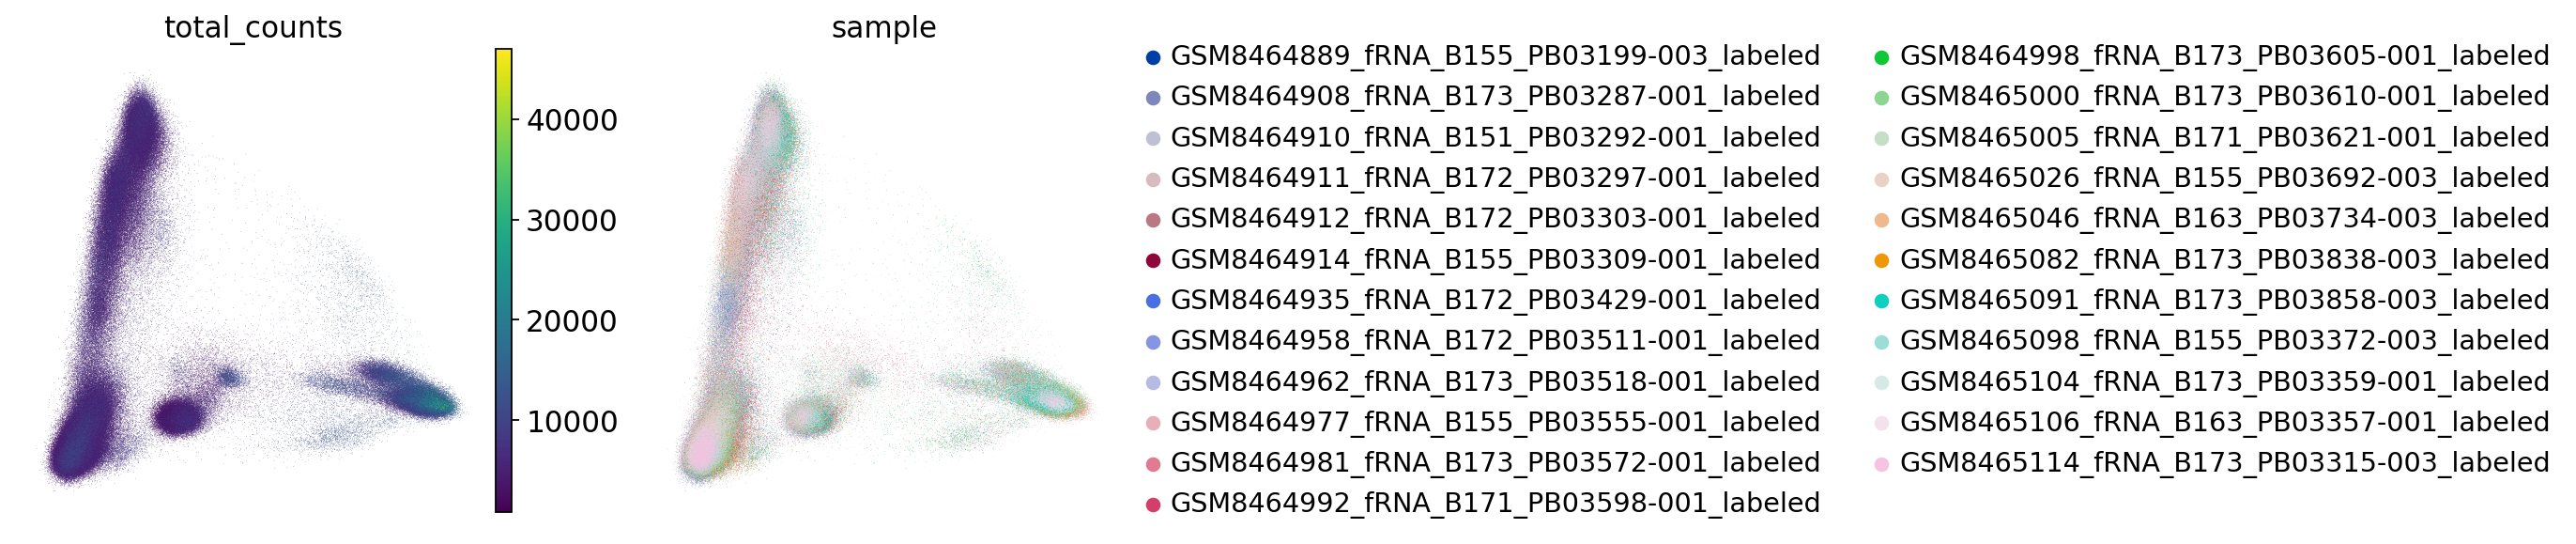

In [6]:
# plot PCA
sc.pl.pca_scatter(adata, color= ["total_counts", "sample"])
# color by total counts, sample and batch to preliminarily check for batch effects

In [7]:
adata.obs

,sample,GSM_id,age,gender,race,age_bin,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,outlier,mt_outlier,n_genes,doublet_score,predicted_doublet
7114ba3cb05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155,2784,7.932003,5028,8.522976,7.219570,69,4.248495,1.372315,False,False,2784,0.092784,False
7114bb22b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155,2068,7.634821,3286,8.097731,6.634206,35,3.583519,1.065125,False,False,2068,0.035918,False
7114bb9ab05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155,3575,8.182000,7048,8.860641,6.143587,101,4.624973,1.433031,False,False,3575,0.063655,False
7114bc12b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155,2549,7.843849,4404,8.390496,7.742961,51,3.951244,1.158038,False,False,2549,0.062298,False
7114bc80b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155,4076,8.313117,8936,9.097955,5.494628,118,4.779123,1.320501,False,False,4076,0.195565,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9e81d7f8bc1211eeb538deb4e32bbba3-22,GSM8465114_fRNA_B173_PB03315-003_labeled,GSM8465114,71.0,Female,Caucasian,70-79,B173,2503,7.825645,4077,8.313362,6.131960,47,3.871201,1.152808,False,False,2503,0.016650,False
9e81d866bc1211eeb538deb4e32bbba3-22,GSM8465114_fRNA_B173_PB03315-003_labeled,GSM8465114,71.0,Female,Caucasian,70-79,B173,2076,7.638680,3346,8.115820,7.710699,55,4.025352,1.643754,False,False,2076,0.025641,False
9e81d94cbc1211eeb538deb4e32bbba3-22,GSM8465114_fRNA_B173_PB03315-003_labeled,GSM8465114,71.0,Female,Caucasian,70-79,B173,2528,7.835579,4413,8.392537,6.027646,59,4.094345,1.336959,False,False,2528,0.033808,False
9e81d9babc1211eeb538deb4e32bbba3-22,GSM8465114_fRNA_B173_PB03315-003_labeled,GSM8465114,71.0,Female,Caucasian,70-79,B173,2852,7.956126,5340,8.583168,6.835206,26,3.295837,0.486891,False,False,2852,0.020533,False


In [8]:
# build neighbour graph (used for leiden clustering and UMAP) using the first 30 principal components (stick with this defualt?)
sc.pp.neighbors(adata, n_pcs=30)

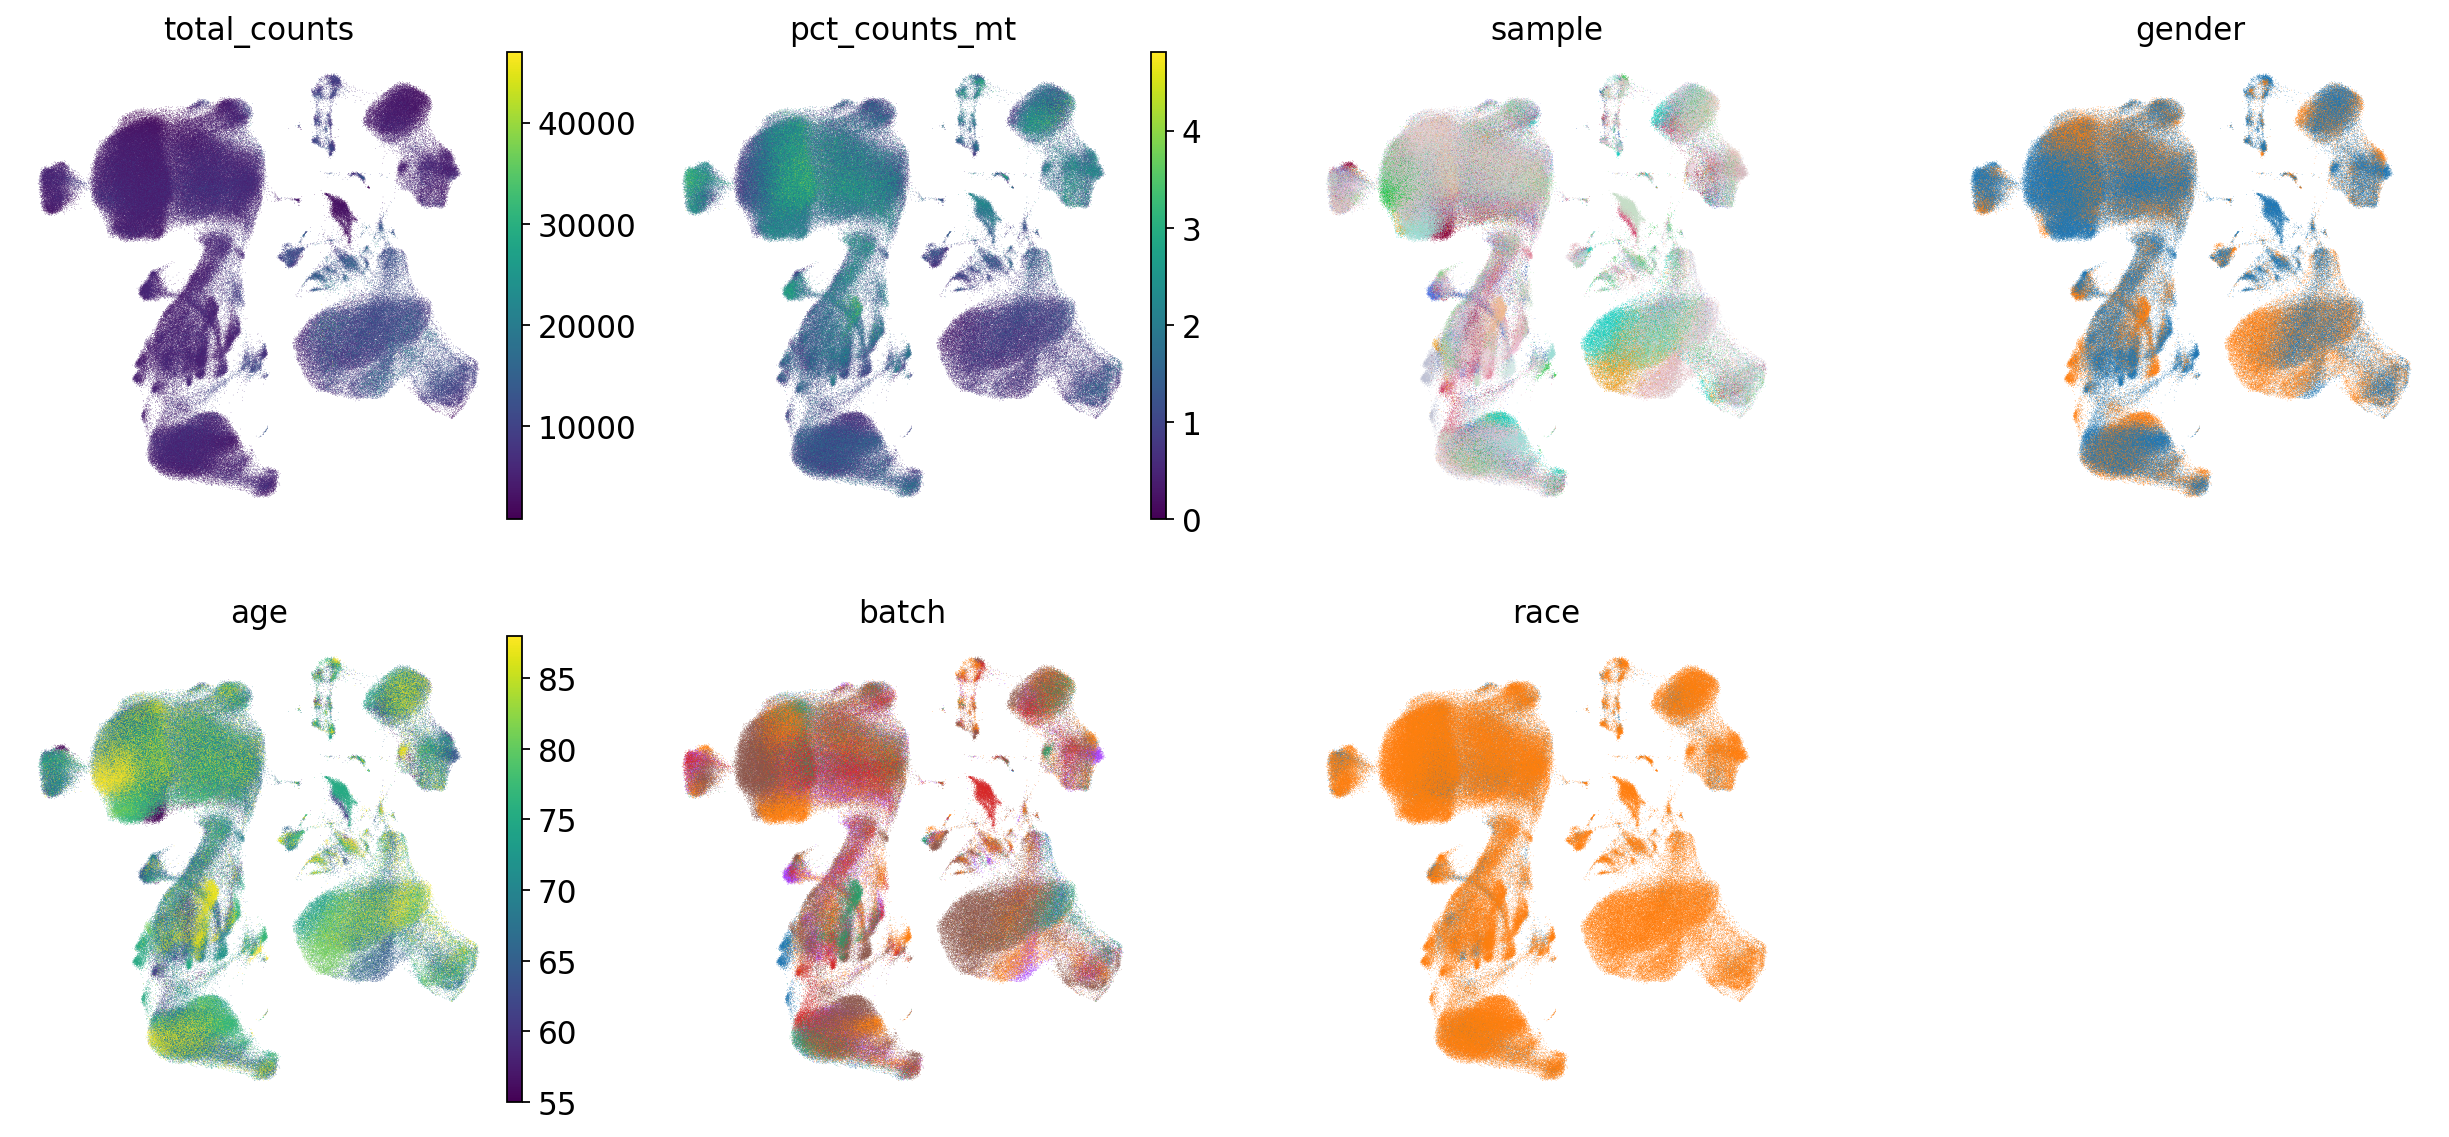

In [9]:
# compute UMAP
sc.tl.umap(adata)

# plot UMAP to check quality control metrics, i.e. see if cells are clustering by non-biological factors
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "sample", "gender", "age", "batch", "race"],
    legend_loc=None
)

# batch correction needed

In [10]:
# batch correction (harmony)


ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "batch")
# adata.obsm["X_pca_harmony"] = ho.Z_corr.T
adata.obsm["X_pca_harmony"] = ho.Z_corr


print(adata.obsm["X_pca_harmony"].shape)


2026-04-21 00:05:27,068 - harmonypy - INFO - Running Harmony (PyTorch on cpu)


Running Harmony (PyTorch on cpu)


2026-04-21 00:05:27,069 - harmonypy - INFO -   Parameters:


  Parameters:


2026-04-21 00:05:27,070 - harmonypy - INFO -     max_iter_harmony: 10


...

2026-04-21 00:09:57,349 - harmonypy - INFO - Iteration 4 of 10


Iteration 4 of 10


2026-04-21 00:10:36,139 - harmonypy - INFO - Converged after 4 iterations


Converged after 4 iterations


(452499, 50)


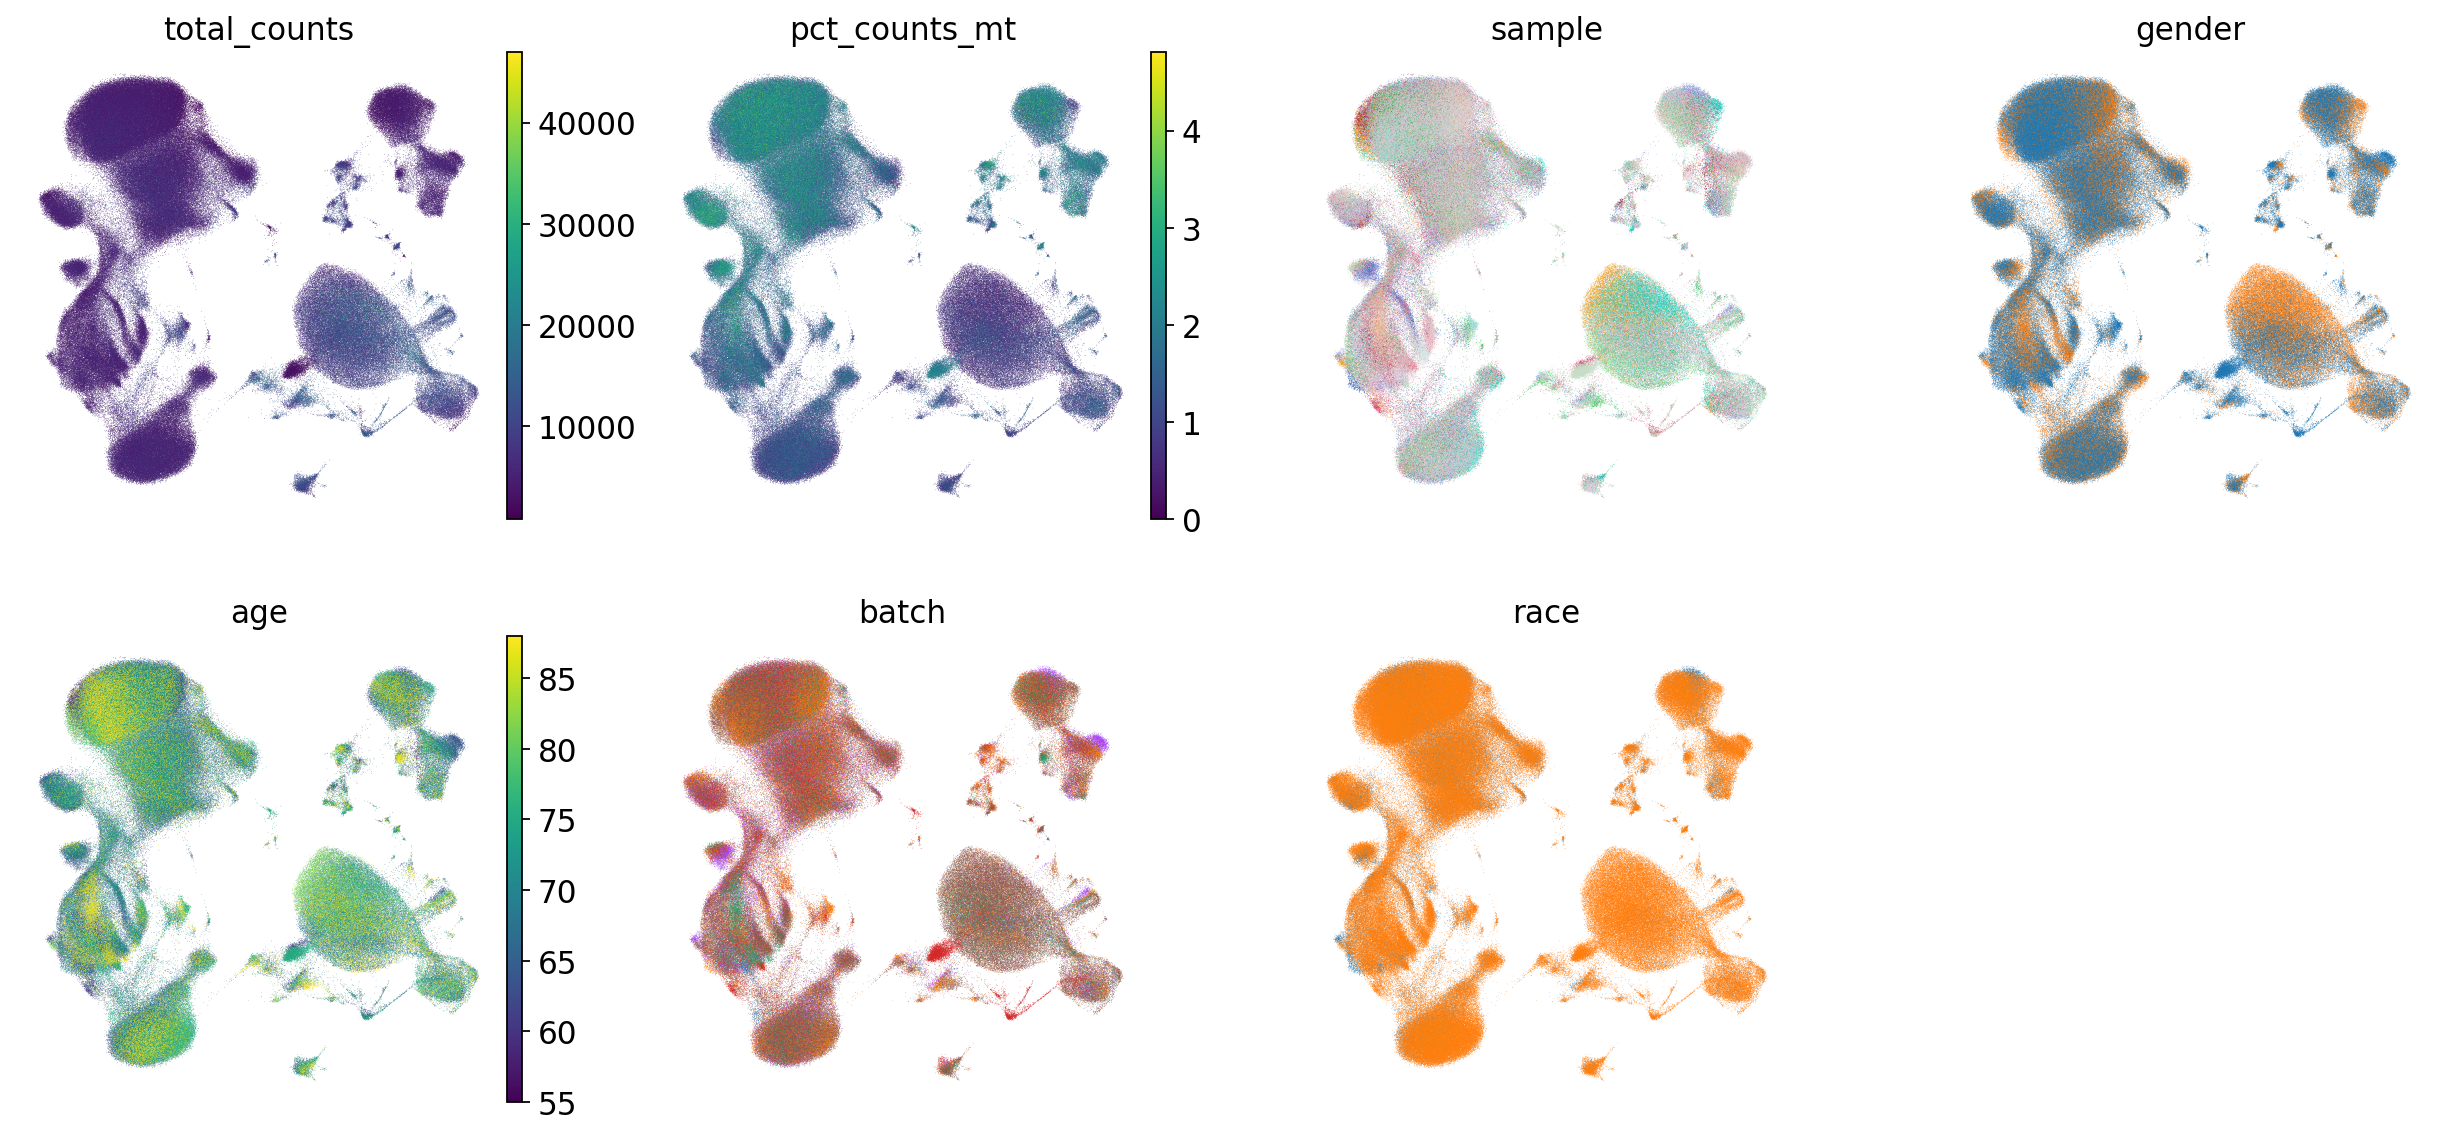

In [11]:
# recompute UMAP and neighbours using corrected data

sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata) # writes to X_umap (default overwritten)

# replot to check for overcorrection

sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "sample", "gender", "age", "batch", "race"],
    legend_loc=None
)

In [12]:
# CellTypist

# first prepare data to format needed for cellTypist (normalised to 10,000 counts per cell then log1p transformed)

adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [13]:
# download celltypist models for immune cells 
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

model_low = models.Model.load(model="Immune_All_Low.pkl") # finer annotation level
model_high = models.Model.load(model="Immune_All_High.pkl") # coarser annotation level

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


📚 Total models in list: 61


📂 Storing models in /rds/general/user/ztb25/home/.celltypist/data/models


💾 Total models to download: 2


💾 Downloading model [1/2]: Immune_All_Low.pkl


💾 Downloading model [2/2]: Immune_All_High.pkl


In [14]:
# run high model 

predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True #?
)

predictions_high_adata = predictions_high.to_adata() # transform predictions to adata for full output

# copy results into original AnnData obj
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 452499 cells and 15430 genes


🔗 Matching reference genes in the model


🧬 4868 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 30


🗳️ Majority voting the predictions


✅ Majority voting done!


In [15]:
# run low model

predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)

predictions_low_adata = predictions_low.to_adata()

adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 452499 cells and 15430 genes


🔗 Matching reference genes in the model


🧬 4868 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 30


🗳️ Majority voting the predictions


✅ Majority voting done!


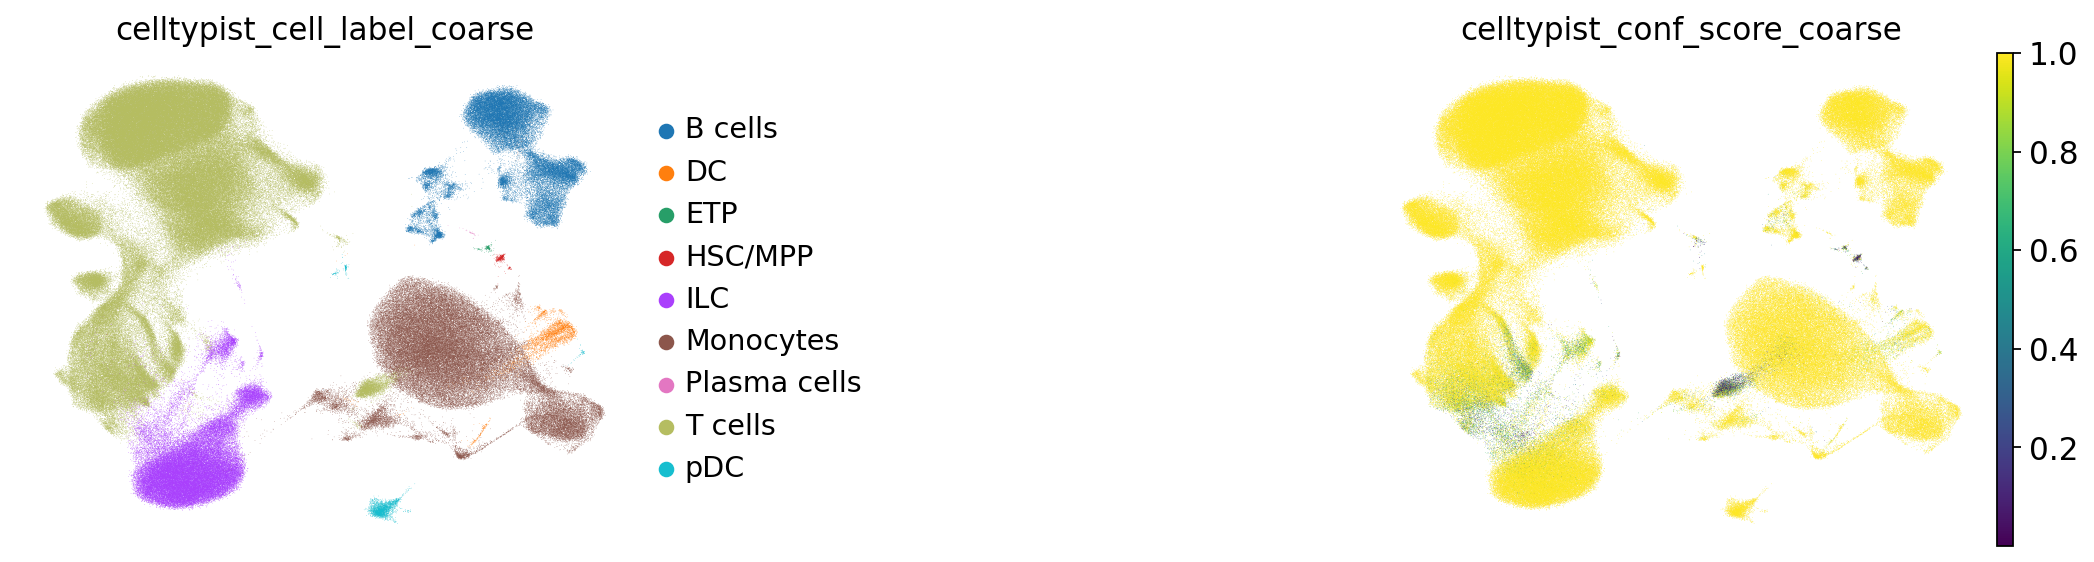

In [16]:
# plot (coarse)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
)


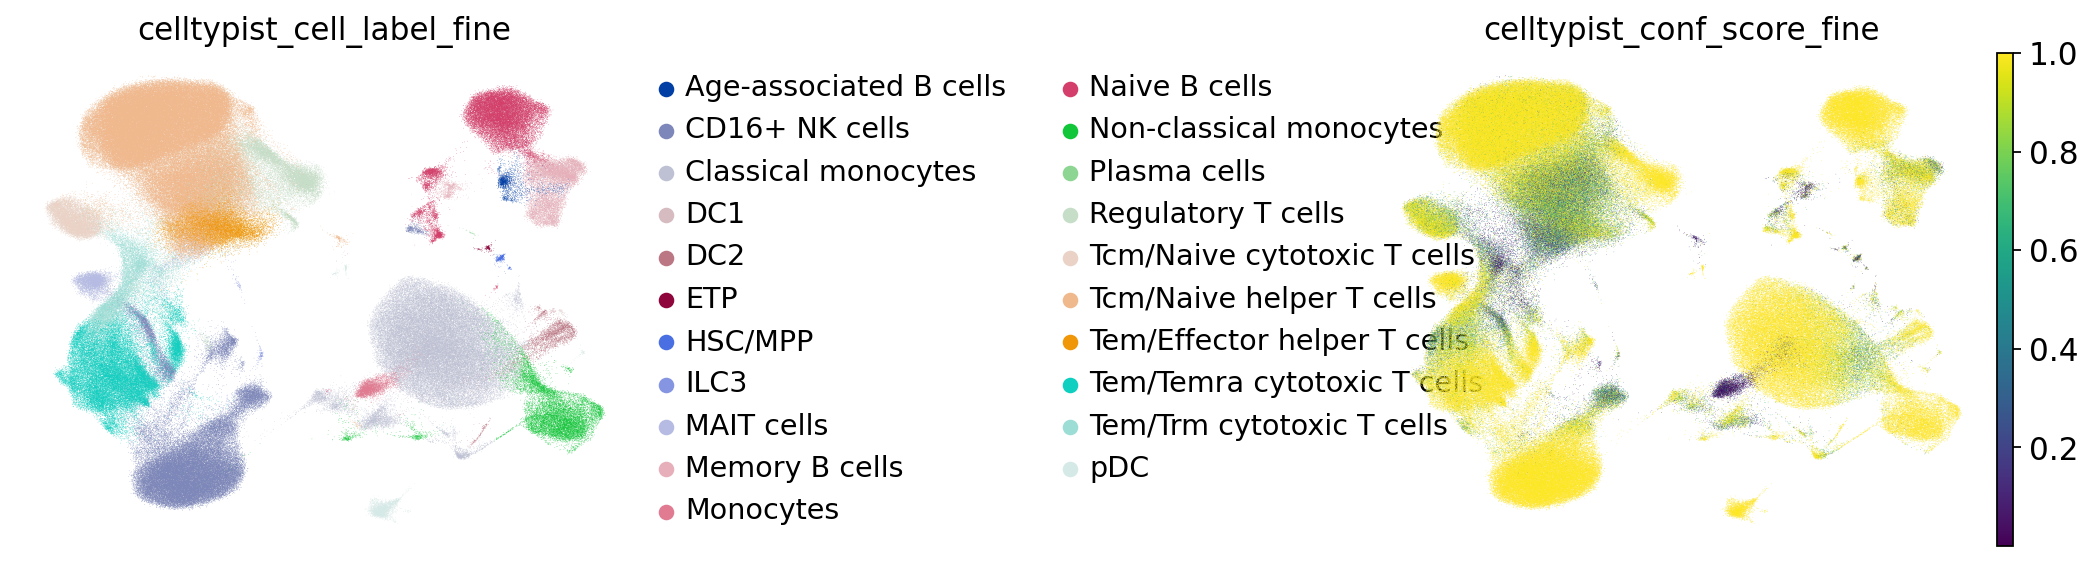

In [17]:
# plot (fine)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

In [ ]:
# reannotate monocytes

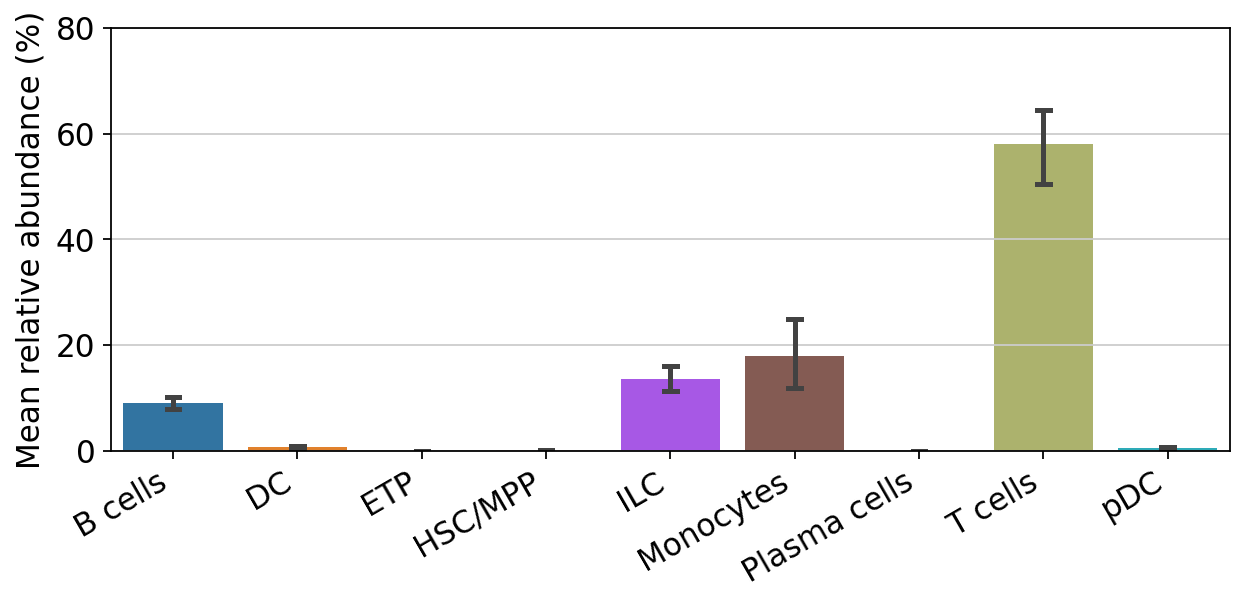

In [ ]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

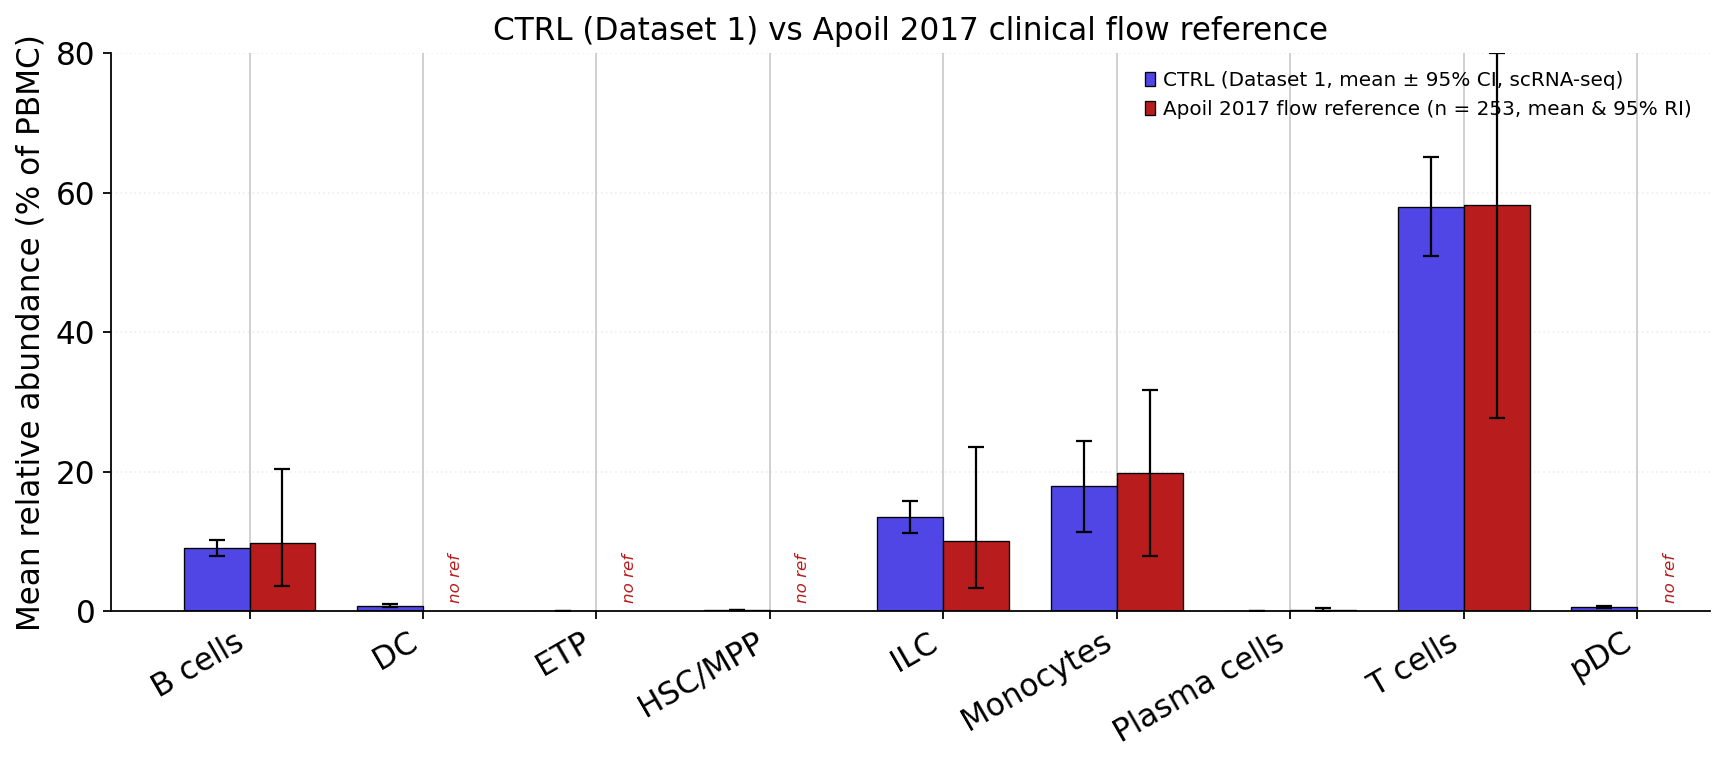

In [19]:
# plot paired with reference to check proportions are within normal range

# ---------- Apoil 2017 reference, scaled to % of PBMC ----------
# PBMC denominator: Apoil lymph (2012/µL) + clinical mono ref (500/µL)
# + Autissier DCs (15/µL) ≈ 2527 cells/µL
PBMC_MEAN = 2012 + 500 + 15

# cluster, mean_count, lo_count, hi_count
apoil_rows = [
    ("T cells",                   1473,  700, 2508),
    ("B cells",                    247,   92,  515),
    ("ILC",                        253,   82,  594),
    ("Monocytes",                  500,  200,  800),   # clinical reference, not Apoil
    ("Plasma cells",               3.2,  0.5, 12.4),   # Apoil plasmablasts × B count
    ("DC",                        None, None, None),   # not covered
    ("pDC",                       None, None, None),
    ("Megakaryocytes/platelets",  None, None, None),
]
apoil_ref = pd.DataFrame(
    apoil_rows,
    columns=["celltypist_cell_label_coarse", "mean_count", "lo_count", "hi_count"],
)
apoil_ref["apoil_mean"] = apoil_ref["mean_count"] / PBMC_MEAN * 100
apoil_ref["apoil_lo"]   = apoil_ref["lo_count"]   / PBMC_MEAN * 100
apoil_ref["apoil_hi"]   = apoil_ref["hi_count"]   / PBMC_MEAN * 100
# cap the T-cell upper bound at ~80 so the y axis doesn't break
apoil_ref.loc[apoil_ref["celltypist_cell_label_coarse"] == "T cells", "apoil_hi"] = 80.0

# ---------- aggregate your CTRL: mean + 95% CI per cluster ----------
ctrl_stats = (
    plot_df
    .groupby("celltypist_cell_label_coarse", observed=True)["rel_abundance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
ctrl_stats["ci95"] = 1.96 * ctrl_stats["std"] / np.sqrt(ctrl_stats["count"])

# merge, keeping CTRL order as the x-axis
df = (
    ctrl_stats
    .merge(apoil_ref, on="celltypist_cell_label_coarse", how="left")
    .rename(columns={"mean": "ctrl_mean"})
)

# ---------- paired bar plot ----------
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.38

# your CTRL (blue) — mean ± 95% CI
ax.bar(
    x - w/2, df["ctrl_mean"], w,
    yerr=df["ci95"], capsize=3.5,
    color="#4f46e5", edgecolor="black", linewidth=0.6,
    label="CTRL (Dataset 1, mean ± 95% CI, scRNA-seq)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# Apoil reference (red) — mean with asymmetric 95% RI
err_lo = (df["apoil_mean"] - df["apoil_lo"]).astype(float)
err_hi = (df["apoil_hi"]   - df["apoil_mean"]).astype(float)
ax.bar(
    x + w/2, df["apoil_mean"], w,
    yerr=[err_lo, err_hi], capsize=3.5,
    color="#b91c1c", edgecolor="black", linewidth=0.6,
    label="Apoil 2017 flow reference (n = 253, mean & 95% RI)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# mark clusters with no reference
for i, row in df.iterrows():
    if pd.isna(row["apoil_mean"]):
        ax.text(i + w/2, 1.2, "no ref", ha="center", va="bottom",
                rotation=90, color="#b91c1c", fontsize=7.5, style="italic")

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(df["celltypist_cell_label_coarse"], rotation=30, ha="right")
ax.set_ylabel("Mean relative abundance (% of PBMC)")
ax.set_xlabel("")
ax.set_title("CTRL (Dataset 1) vs Apoil 2017 clinical flow reference")
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 20))
ax.grid(axis="y", linestyle=":", alpha=0.3)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad")